<a href="https://colab.research.google.com/github/deadex-ng/arena/blob/main/chapter1_transformer_interp/exercises/part1_transformer_from_scratch/ViT_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.utils.data as dataloader
import torch.nn as nn
import numpy as np

In [2]:
transformation_operation = transforms.Compose([transforms.ToTensor()])

In [3]:
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform = transformation_operation)
val_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform= transformation_operation)

100%|██████████| 9.91M/9.91M [00:00<00:00, 22.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 605kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 5.60MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.13MB/s]


In [4]:
num_classes = 10
batch_size = 64
num_channels = 1
img_size = 28
patch_size = 7
num_patches = (img_size // patch_size) **2
embedding_dim = 64
attention_heads = 4
transformer_blocks = 4
mlp_hidden_nodes = 128
learning_rate = 0.001
epochs = 5

In [5]:
# Define dataset batches
train_loader = dataloader.DataLoader(train_dataset, batch_size = batch_size, shuffle=True)
val_loader = dataloader.DataLoader(val_dataset, batch_size = batch_size, shuffle=True)


In [6]:
class PatchEmbedding(nn.Module):
  def __init__(self):
    super().__init__()
    self.patch_embed = nn.Conv2d(num_channels, embedding_dim, kernel_size=patch_size, stride = patch_size)

  def forward(self, x):
    x = self.patch_embed(x)
    x = x.flatten(2)
    x = x.transpose(1,2)

    return x


In [7]:
class TransformerEncoder(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_norm1 = nn.LayerNorm(embedding_dim)
    self.layer_norm2 = nn.LayerNorm(embedding_dim)
    self.multihead_attention = nn.MultiheadAttention(embedding_dim, attention_heads, batch_first=True)
    self.mlp = nn.Sequential(
        nn.Linear(embedding_dim, mlp_hidden_nodes),
        nn.GELU(),
        nn.Linear(mlp_hidden_nodes, embedding_dim)
    )
  def forward(self,x):
    residual1 = x
    x = self.layer_norm1(x)
    x = self.multihead_attention(x, x, x)[0]
    x = x + residual1

    residual2 = x
    x = self.layer_norm2(x)
    x = self.mlp(x)
    x = x + residual2

    return x


In [8]:
class MLP_head(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_norm1 = nn.LayerNorm(embedding_dim)
    self.mlp_head = nn.Linear(embedding_dim, num_classes)

  def forward(self, x):
    x = self.layer_norm1(x)
    x = self.mlp_head(x)

    return x

In [9]:
class VisionTransformer(nn.Module):
  def __init__(self):
    super().__init__()
    self.patch_embedding = PatchEmbedding()
    self.cls_token = nn.Parameter(torch.randn(1,1,embedding_dim))
    self.position_embedding = nn.Parameter(torch.randn(1,num_patches+1, embedding_dim))
    self.transformer_blocks = nn.Sequential(*[TransformerEncoder() for _ in range(transformer_blocks)])
    self.mlp_head = MLP_head()

  def forward(self,x):
     x = self.patch_embedding(x)
     B = x.size(0)
     class_tokens = self.cls_token.expand(B, -1, -1)
     x = torch.cat((class_tokens,x), dim=1)
     x = x + self.position_embedding
     x = self.transformer_blocks(x)
     x = x [:,0]
     x = self.mlp_head(x)

     return x

In [10]:
def mixup_data(x, y, alpha=1.0):
  if alpha > 0:
    lam = np.random.beta(alpha, alpha)
  else:
      lam = 1
  batch_size = x.size(0)
  index = torch.randperm(batch_size).to(x.device)

  mixed_x = lam * (1-lam) * x[index, :]
  y_a, y_b = y, y[index]

  return mixed_x, y_a, y_b, lam

In [11]:
def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

In [12]:
device = torch.device('cude' if torch.cuda.is_available() else 'cpu')
model = VisionTransformer().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate)
criterion = nn.CrossEntropyLoss()

In [25]:
for epoch in range(epochs):
  model.train()
  total_loss = 0
  correct_epoch = 0
  total_epoch = 0
  print(f"\nEpoch {epoch+1}")
  for batch_idx, (images, labels) in enumerate(train_loader):
    images, labels = images.to(device), labels.to(device)
    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels)
    # images, targets_a, targets_b, lam = mixup_data(images, labels)

    # outputs = model(images)
    # loss = mixup_criterion(criterion, outputs, targets_a, targets_b, lam)
    loss.backward()
    optimizer.step()
    total_loss += loss.item()
    preds = outputs.argmax(dim=1)
    correct = (preds == labels).sum().item()
    # preds = outputs.argmax(dim=1)
    # correct = (lam * preds.eq(targets_a).sum().item() +
    #        (1 - lam) * preds.eq(targets_b).sum().item())
    accuracy = 100.0 * correct / labels.size(0)

    correct_epoch += correct
    total_epoch += labels.size(0)

    if batch_idx % 100 == 0:
      print(f" Batch {batch_idx+1:3d}: Loss = {loss.item():.4f}, Accuracy = {accuracy:.2f}%")

  epoch_acc = 100.0 * correct_epoch / total_epoch
  print(f"==> Epoch {epoch+1} Summary: Total Loss = {total_loss:.4f}, Accuracy = {epoch_acc:.2f}%")






Epoch 1
 Batch   1: Loss = 1.5471, Accuracy = 60.94%
 Batch 101: Loss = 0.2770, Accuracy = 93.75%
 Batch 201: Loss = 0.1436, Accuracy = 95.31%
 Batch 301: Loss = 0.3191, Accuracy = 92.19%
 Batch 401: Loss = 0.3368, Accuracy = 92.19%
 Batch 501: Loss = 0.0430, Accuracy = 100.00%
 Batch 601: Loss = 0.1077, Accuracy = 96.88%
 Batch 701: Loss = 0.1366, Accuracy = 96.88%
 Batch 801: Loss = 0.1671, Accuracy = 95.31%
 Batch 901: Loss = 0.1358, Accuracy = 96.88%
==> Epoch 1 Summary: Total Loss = 202.6909, Accuracy = 94.04%

Epoch 2
 Batch   1: Loss = 0.0743, Accuracy = 98.44%
 Batch 101: Loss = 0.1690, Accuracy = 95.31%
 Batch 201: Loss = 0.0213, Accuracy = 100.00%
 Batch 301: Loss = 0.1828, Accuracy = 93.75%
 Batch 401: Loss = 0.2742, Accuracy = 92.19%
 Batch 501: Loss = 0.0167, Accuracy = 100.00%
 Batch 601: Loss = 0.1064, Accuracy = 96.88%
 Batch 701: Loss = 0.0237, Accuracy = 98.44%
 Batch 801: Loss = 0.0132, Accuracy = 100.00%
 Batch 901: Loss = 0.0159, Accuracy = 100.00%
==> Epoch 2 Sum

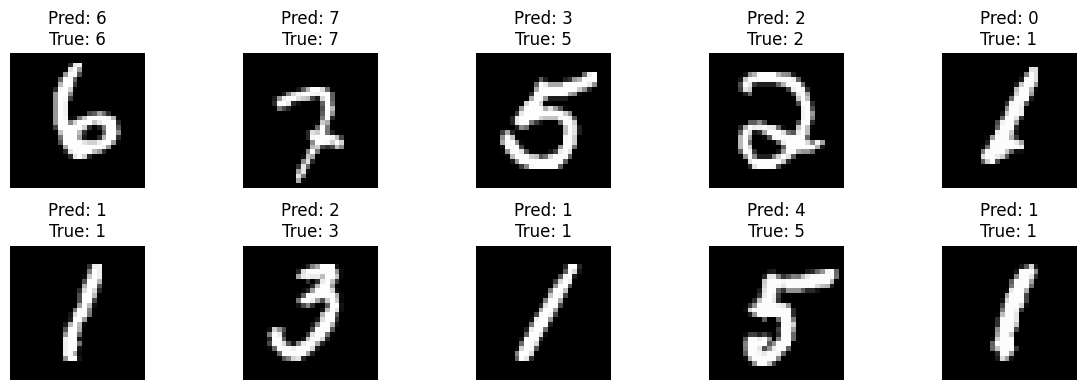

In [14]:
import matplotlib.pyplot as plt

model.eval()
images, labels = next(iter(val_loader))
images, labels = images.to(device), labels.to(device)
with torch.no_grad():
  outputs = model(images)
  preds = outputs.argmax(dim=1)

images = images.cpu()
preds = preds.cpu()
labels = labels.cpu()

# Plot first 10 images
plt.figure(figsize=(12,4))
for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(images[i].squeeze(), cmap='gray')
  plt.title(f"Pred: {preds[i].item()}\nTrue: {labels[i].item()}")
  plt.axis('off')
plt.tight_layout()
plt.show()

In [23]:
import matplotlib.pyplot as plt

# Get a batch
images, labels = next(iter(train_loader))
images, labels = images.to(device), labels.to(device)

# Apply mixup
mixed_images, targets_a, targets_b, lam = mixup_data(images, labels, alpha=0.01)

# Move to CPU for plotting
mixed_images = mixed_images.cpu()
images = images.cpu()
targets_a = targets_a.cpu()
targets_b = targets_b.cpu()

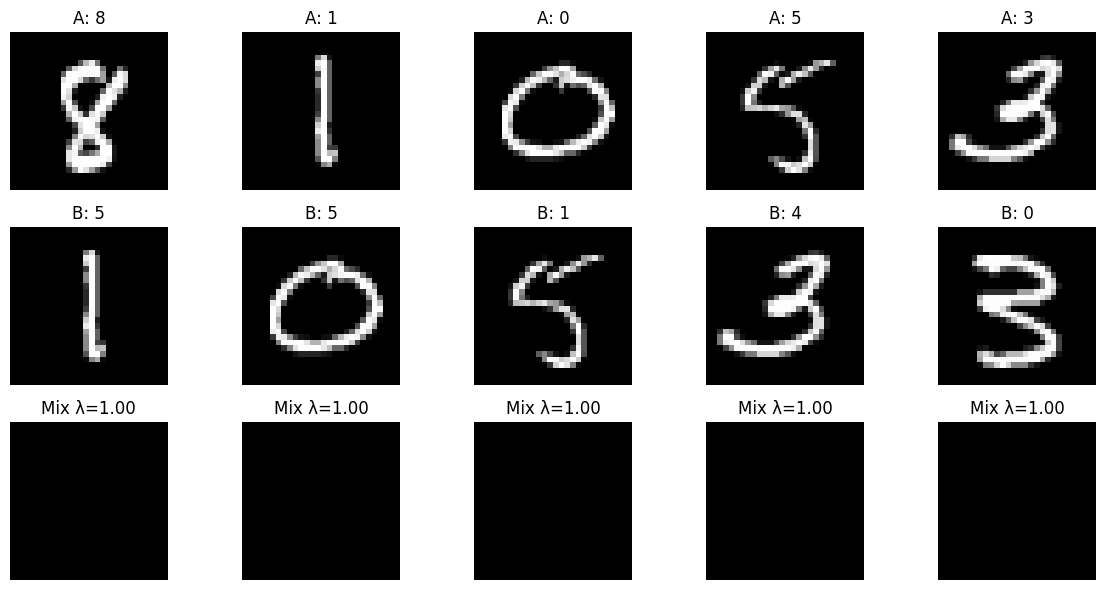

In [24]:
plt.figure(figsize=(12,6))

for i in range(5):
    # Original image A
    plt.subplot(3,5,i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title(f"A: {targets_a[i].item()}")
    plt.axis('off')

    # Original image B
    plt.subplot(3,5,i+6)
    plt.imshow(images[i+1].squeeze(), cmap='gray')
    plt.title(f"B: {targets_b[i].item()}")
    plt.axis('off')

    # Mixed image
    plt.subplot(3,5,i+11)
    plt.imshow(mixed_images[i].squeeze(), cmap='gray')
    plt.title(f"Mix λ={lam:.2f}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [15]:
data_point, label = next(iter(train_loader))
print("Shape of data point: ", data_point.shape)
patch_embed = nn.Conv2d(num_channels, embedding_dim, kernel_size=patch_size, stride = patch_size)
patch_embed_output = patch_embed(data_point)
print(patch_embed_output.shape)
patch_embed_output_flatten = patch_embed_output.flatten(2)
print(patch_embed_output_flatten.shape)
patch_embed_output_flatten_transpose_output = patch_embed_output_flatten.transpose(1,2)
print(patch_embed_output_flatten_transpose_output.shape)

Shape of data point:  torch.Size([64, 1, 28, 28])
torch.Size([64, 64, 4, 4])
torch.Size([64, 64, 16])
torch.Size([64, 16, 64])
